In [2]:
import tensorflow as tf
print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.16.2
GPU : []


# 1. SETUP

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

gpus = tf.config.list_physical_devices('GPU')
if gpus :
    for gpu in gpus :
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: enabled')
    except Exception as e :
        print('Mixed precision: disabled ->', e)
else :
    print('GPU not detected, using CPU only')

GPU not detected, using CPU only


# 2. CONFIG

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 50 # Bisa diubah
FINE_TUNE_EPOCHS = 25 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10
EARLY_STOP_START_EPOCH = 3

# 3. LOAD DATASET

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalisasi dataset ke rentang [0, 1] sebelum masuk ke model
train_gen = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_gen = ImageDataGenerator(rescale=1.0 / 255.0)

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

Found 2240 images belonging to 4 classes.
Found 240 images belonging to 4 classes.
Found 240 images belonging to 4 classes.


# 4. CALLBACK

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/best_model.h5", save_best_only = True),
    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        min_lr = 1e-7,
        verbose = 1
    )
]

# EarlyStopping opsional: aktifkan jika ingin hentikan training otomatis
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStopping(
            monitor = 'val_loss',
            patience = EARLY_STOP_PATIENCE,
            start_from_epoch = EARLY_STOP_START_EPOCH,
            restore_best_weights = True,
            verbose = 1
        )
    )

# 5. FUNCTION EVALUASI

In [ ]:
def _collect_full_test_set(generator) :
    generator.reset()
    x_batches, y_batches = [], []
    for _ in range(len(generator)) :
        x_batch, y_batch = next(generator)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis = 0)
    y_true = np.argmax(np.concatenate(y_batches, axis = 0), axis = 1)
    return x_test, y_true

def evaluate_model(model, model_name, return_details = False, show_plot = True):
    print(f"\n=== {model_name} ===")

    # Evaluasi loss/akurasi pada test generator
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose = 0)
    print("Accuracy :", acc)
    print("Loss :", loss)

    # Prediksi menggunakan array penuh agar bentuk tensor konsisten
    x_test, y_true = _collect_full_test_set(test_data)
    y_prob = model.predict(x_test, batch_size = BATCH_SIZE, verbose = 0)
    y_pred = np.argmax(y_prob, axis = 1)

    class_names = [
        name
        for name, _ in sorted(test_data.class_indices.items(), key = lambda item : item[1])
    ]

    report_text = classification_report(
        y_true,
        y_pred,
        target_names = class_names,
        zero_division = 0
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names = class_names,
        zero_division = 0,
        output_dict = True
    )

    print("\nClassification Report :")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    if show_plot :
        plt.figure(figsize = (6, 5))
        sns.heatmap(cm, annot = True, fmt = 'd', xticklabels = class_names, yticklabels = class_names)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    if return_details :
        return {
            "model_name" : model_name,
            "accuracy" : float(acc),
            "loss" : float(loss),
            "y_true" : y_true,
            "y_pred" : y_pred,
            "y_prob" : y_prob,
            "class_names" : class_names,
            "report_dict" : report_dict,
            "confusion_matrix": cm
        }

    return acc

# 6. MODEL

## A. MobileNetV2 (Tanpa Pretrained - Belajar dari 0)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model - TANPA PRETRAINED
def build_mobilenet() :
    input_layer = tf.keras.Input(shape = (224, 224, 3))
    
    # Data sudah dinormalisasi [0, 1], kembalikan ke [0, 255] sebelum preprocess_input
    x = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    
    # weights=None untuk tidak menggunakan pretrained ImageNet
    base = MobileNetV2(weights = None, include_top = False, input_tensor = x)
    base.trainable = True
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation = 'relu')(x)
    x = layers.Dropout(0.5)(x)
    
    output = layers.Dense(4, activation = 'softmax', dtype = 'float32')(x)
    
    model = models.Model(inputs = input_layer, outputs = output)
    return model, base

## B. EfficientNetB0 (Tanpa Pretrained - Belajar dari 0)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model - TANPA PRETRAINED
def build_efficientnet():
    input_layer = tf.keras.Input(shape = (224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)
    
    # weights=None untuk tidak menggunakan pretrained ImageNet
    base = EfficientNetB0(weights = None, include_top = False, input_tensor = x)
    base.trainable = True
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation = 'relu')(x)
    x = layers.Dropout(0.5)(x)
    
    output = layers.Dense(4, activation = 'softmax', dtype = 'float32')(x)
    
    model = models.Model(inputs = input_layer, outputs = output)
    return model, base

## C. Hybrid (Feature Fusion)

In [ ]:
def build_fusion():
    input_layer = tf.keras.Input(shape = (224, 224, 3))
    
    # Dataset sudah [0,1], ubah dulu ke [0,255] agar preprocessing backbone sesuai
    mob_in = layers.Lambda(
        lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0)
    )(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)
    
    # weights=None untuk kedua backbone - tidak menggunakan pretrained ImageNet
    base1 = MobileNetV2(weights = None, include_top = False, input_tensor = mob_in)
    base2 = EfficientNetB0(weights = None, include_top = False, input_tensor = eff_in)
    
    base1.trainable = True
    base2.trainable = True
    
    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)
    
    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)
    
    fusion = layers.concatenate([x1, x2])
    
    x = layers.Dense(256, activation = 'relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    output = layers.Dense(4, activation = 'softmax', dtype = 'float32')(x)
    
    model = models.Model(inputs = input_layer, outputs = output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [ ]:
import time

def train_model(model, base_model=None) :
    # Tahap 1: Training awal dengan learning rate lebih tinggi
    model.compile(
        optimizer = tf.keras.optimizers.Adam(INITIAL_LR),
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )
    
    stage1_start = time.perf_counter()
    history_stage1 = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    stage1_time = time.perf_counter() - stage1_start
    
    # Tahap 2: Training lanjutan dengan learning rate lebih rendah
    model.compile(
        optimizer = tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )
    
    stage2_start = time.perf_counter()
    history_stage2 = model.fit(
        train_data,
        validation_data = val_data,
        epochs = FINE_TUNE_EPOCHS,
        callbacks = callbacks
    )
    stage2_time = time.perf_counter() - stage2_start
    
    history_bundle = {
        "stage1" : history_stage1.history,
        "stage2" : history_stage2.history,
    }
    timing_bundle = {
        "stage1_sec" : stage1_time,
        "stage2_sec" : stage2_time,
        "total_sec" : stage1_time + stage2_time,
    }
    
    return model, history_bundle, timing_bundle

# 8. Train & Evaluasi Model

## A. MobileNetV2


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2557 - loss: 2.0158

70/70 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.2772 - loss: 1.8651 - val_accuracy: 0.2375 - val_loss: 1.4033 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3295 - loss: 1.5735 - val_accuracy: 0.2375 - val_loss: 1.4443 - learning_rate: 1.0000e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3513 - loss: 1.4882 - val_accuracy: 0.2375 - val_loss: 1.4846 - learning_rate: 1.0000e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3883 - loss: 1.4117
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3848 - loss: 1.4253 - val_accuracy: 0.2375 - val_loss: 1.6349 - learning_rate: 1.0000e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.4330 - loss: 1.2936 - val_accuracy: 0.2375 - val_loss: 1.6935 - learning_rate: 5.0000e-05
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4357 - loss: 1.2676 - val_ac

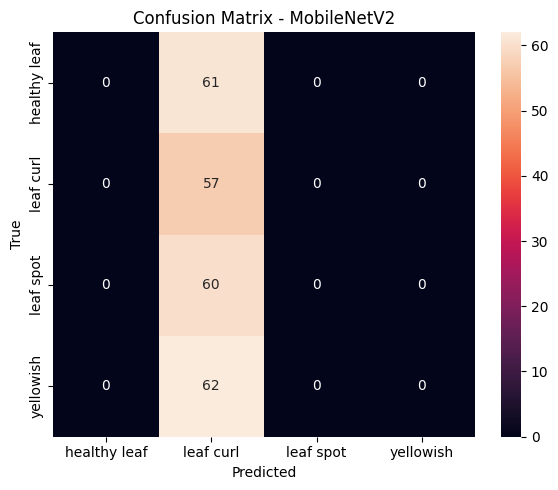

In [ ]:
model_m, base_m = build_mobilenet()
model_m, history_m, timing_m = train_model(model_m, base_m)
eval_m = evaluate_model(model_m, "MobileNetV2", return_details = True)
acc_m = eval_m["accuracy"]

## B. EfficientNetB0

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2615 - loss: 1.7413

70/70 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.2638 - loss: 1.6892 - val_accuracy: 0.2542 - val_loss: 1.3871 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.2821 - loss: 1.5443 - val_accuracy: 0.2542 - val_loss: 1.3969 - learning_rate: 1.0000e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.3116 - loss: 1.4565 - val_accuracy: 0.2542 - val_loss: 1.4249 - learning_rate: 1.0000e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3487 - loss: 1.4275
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.3241 - loss: 1.4287 - val_accuracy: 0.2542 - val_loss: 1.4212 - learning_rate: 1.0000e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.3571 - loss: 1.3673 - val_accuracy: 0.2542 - val_loss: 1.5145 - learning_rate: 5.0000e-05
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.3754 - loss: 1.3253 - v

70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4121 - loss: 1.2687 - val_accuracy: 0.3000 - val_loss: 1.3450 - learning_rate: 2.5000e-05
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4181 - loss: 1.2649

70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4228 - loss: 1.2470 - val_accuracy: 0.3375 - val_loss: 1.3256 - learning_rate: 2.5000e-05
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4530 - loss: 1.2298

70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.4446 - loss: 1.2406 - val_accuracy: 0.3667 - val_loss: 1.3035 - learning_rate: 2.5000e-05
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4387 - loss: 1.2173

...

70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5063 - loss: 1.1302 - val_accuracy: 0.4542 - val_loss: 1.2525 - learning_rate: 2.5000e-05
Epoch 18/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5210 - loss: 1.0940 - val_accuracy: 0.4375 - val_loss: 1.2795 - learning_rate: 2.5000e-05
Epoch 19/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5042 - loss: 1.1339

70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5246 - loss: 1.1026 - val_accuracy: 0.4750 - val_loss: 1.2425 - learning_rate: 2.5000e-05
Epoch 20/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5431 - loss: 1.0680

70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5473 - loss: 1.0583 - val_accuracy: 0.4875 - val_loss: 1.2366 - learning_rate: 2.5000e-05
Epoch 21/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5339 - loss: 1.0815 - val_accuracy: 0.4625 - val_loss: 1.2422 - learning_rate: 2.5000e-05
Epoch 22/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.5629 - loss: 1.0373 - val_accuracy: 0.4375 - val_loss: 1.2513 - learning_rate: 2.5000e-05
Epoch 23/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5536 - loss: 1.0573

70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.5790 - loss: 1.0144 - val_accuracy: 0.4958 - val_loss: 1.2323 - learning_rate: 2.5000e-05
Epoch 24/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.5772 - loss: 0.9871 - val_accuracy: 0.4708 - val_loss: 1.2336 - learning_rate: 2.5000e-05
Epoch 25/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.5982 - loss: 0.9779 - val_accuracy: 0.4792 - val_loss: 1.2479 - learning_rate: 2.5000e-05
Epoch 26/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6190 - loss: 0.9494

70/70 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.6107 - loss: 0.9398 - val_accuracy: 0.4792 - val_loss: 1.2266 - learning_rate: 2.5000e-05
Epoch 27/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6080 - loss: 0.9205 - val_accuracy: 0.4625 - val_loss: 1.2679 - learning_rate: 2.5000e-05
Epoch 28/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6254 - loss: 0.8872 - val_accuracy: 0.4875 - val_loss: 1.2480 - learning_rate: 2.5000e-05
Epoch 29/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6691 - loss: 0.8594
Epoch 29: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.6567 - loss: 0.8710 - val_accuracy: 0.4917 - val_loss: 1.2488 - learning_rate: 2.5000e-05
Epoch 30/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6585 - loss: 0.8304 - val_accuracy: 0.4792 - val_loss: 1.2592 - learning_rate: 1.2500e-05
Epoch 31/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6576 - loss: 0.82

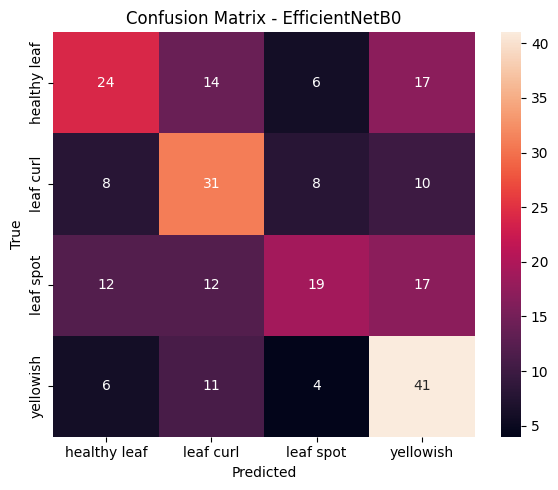

In [ ]:
model_e, base_e = build_efficientnet()
model_e, history_e, timing_e = train_model(model_e, base_e)
eval_e = evaluate_model(model_e, "EfficientNetB0", return_details = True)
acc_e = eval_e["accuracy"]

## C. Hybrid Model

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.2888 - loss: 2.0999 - val_accuracy: 0.2375 - val_loss: 1.3974 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.3308 - loss: 1.8313 - val_accuracy: 0.2542 - val_loss: 1.4402 - learning_rate: 1.0000e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3660 - loss: 1.6538
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.3562 - loss: 1.6879 - val_accuracy: 0.2542 - val_loss: 1.5098 - learning_rate: 1.0000e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - accuracy: 0.3696 - loss: 1.6656 - val_accuracy: 0.2542 - val_loss: 1.7017 - learning_rate: 5.0000e-05
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.3848 - loss: 1.5792 - val_accuracy: 0.2542 - val_loss: 1.8801 - learning_rate: 5.0000e-05
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4158 - loss: 1


Classification Report:
              precision    recall  f1-score   support

healthy leaf       0.00      0.00      0.00        61
   leaf curl       0.00      0.00      0.00        57
   leaf spot       0.25      1.00      0.40        60
   yellowish       0.00      0.00      0.00        62

    accuracy                           0.25       240
   macro avg       0.06      0.25      0.10       240
weighted avg       0.06      0.25      0.10       240



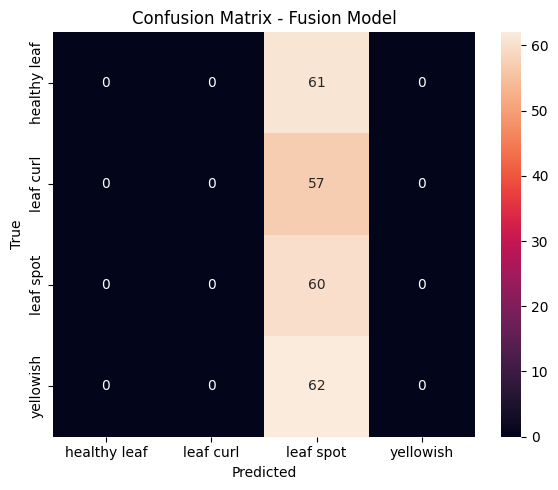

In [14]:
model_f, base1, base2 = build_fusion()

# Tahap 1
model_f.compile(
    optimizer = tf.keras.optimizers.Adam(INITIAL_LR),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
hybrid_stage1_start = time.perf_counter()
history_f_stage1 = model_f.fit(
    train_data,
    validation_data = val_data,
    epochs = EPOCHS,
    callbacks = callbacks
)
hybrid_stage1_time = time.perf_counter() - hybrid_stage1_start

# Tahap 2 (Training lanjutan dengan LR lebih rendah)
model_f.compile(
    optimizer = tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
hybrid_stage2_start = time.perf_counter()
history_f_stage2 = model_f.fit(
    train_data,
    validation_data = val_data,
    epochs = FINE_TUNE_EPOCHS,
    callbacks = callbacks
)
hybrid_stage2_time = time.perf_counter() - hybrid_stage2_start

history_f = {
    "stage1" : history_f_stage1.history,
    "stage2" : history_f_stage2.history,
}
timing_f = {
    "stage1_sec" : hybrid_stage1_time,
    "stage2_sec" : hybrid_stage2_time,
    "total_sec" : hybrid_stage1_time + hybrid_stage2_time
}

eval_f = evaluate_model(model_f, "Fusion Model", return_details = True)
acc_f = eval_f["accuracy"]

# 9. Perbandingan Hasil

In [15]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.23749999701976776
EfficientNet  : 0.4791666567325592
Fusion Model  : 0.25


# 10. Visualisasi Hasil dan Performa 3 Model

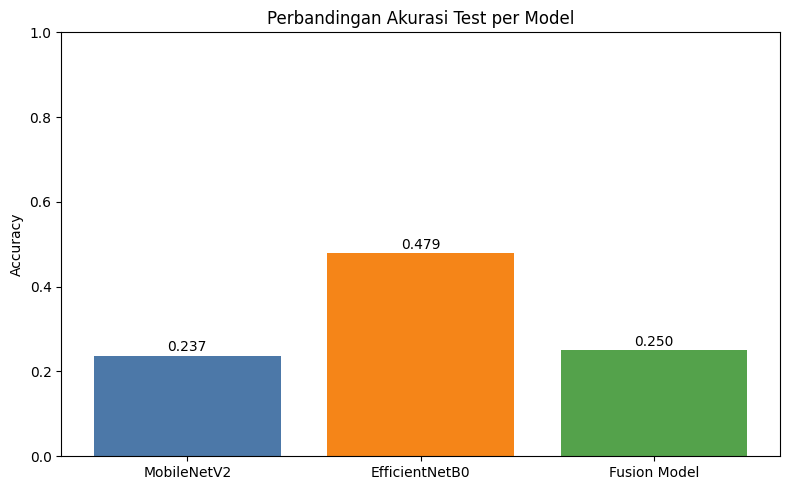

Model akurasi tertinggi: EfficientNetB0 (0.4792)
Peningkatan Hybrid vs MobileNetV2: +1.25%


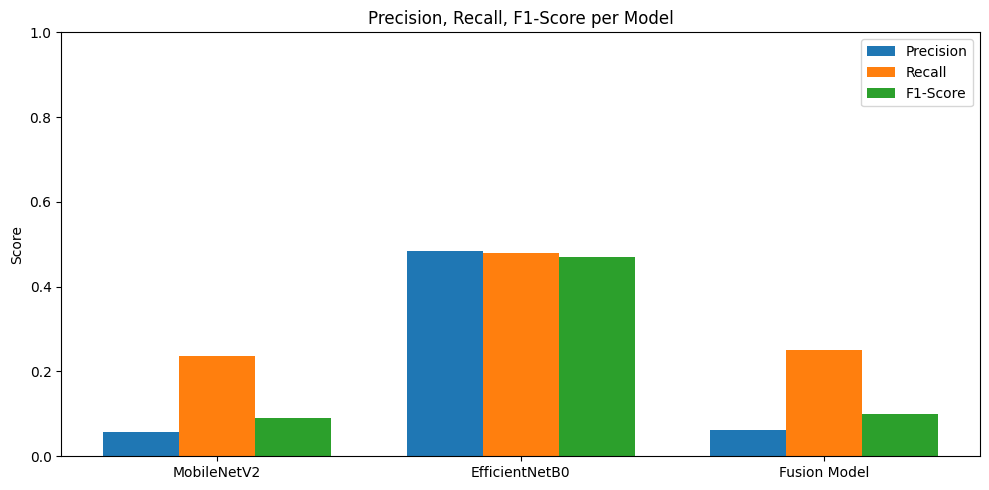

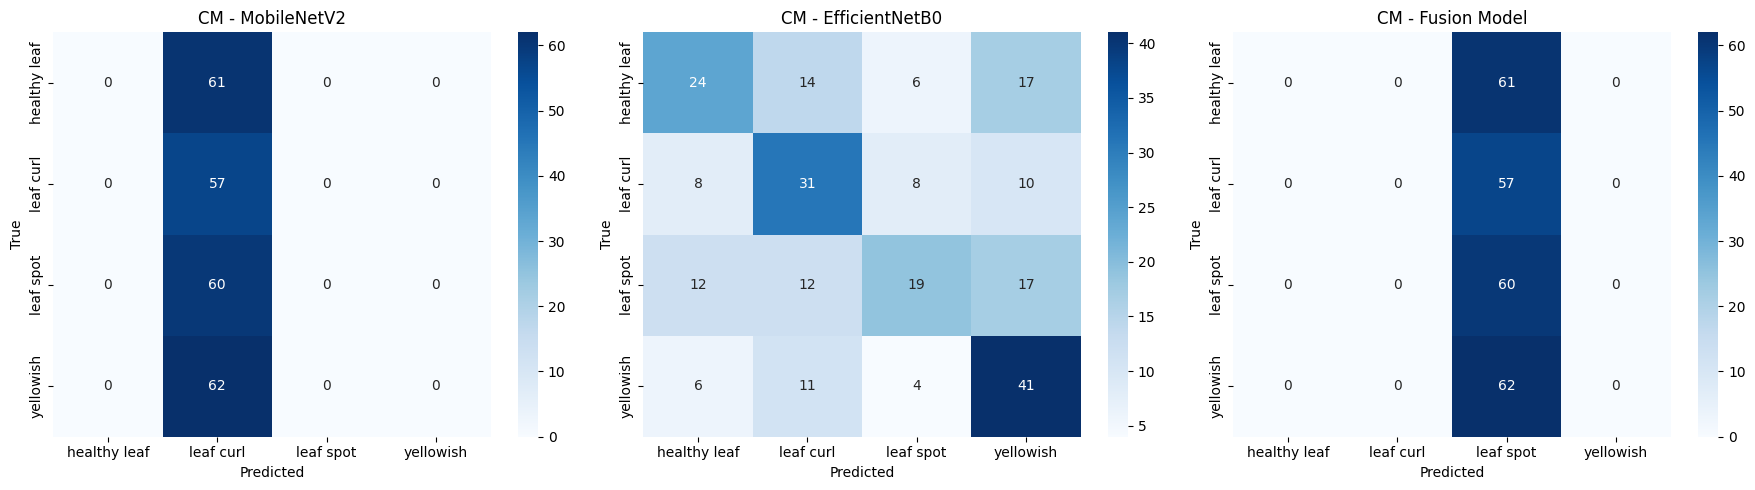

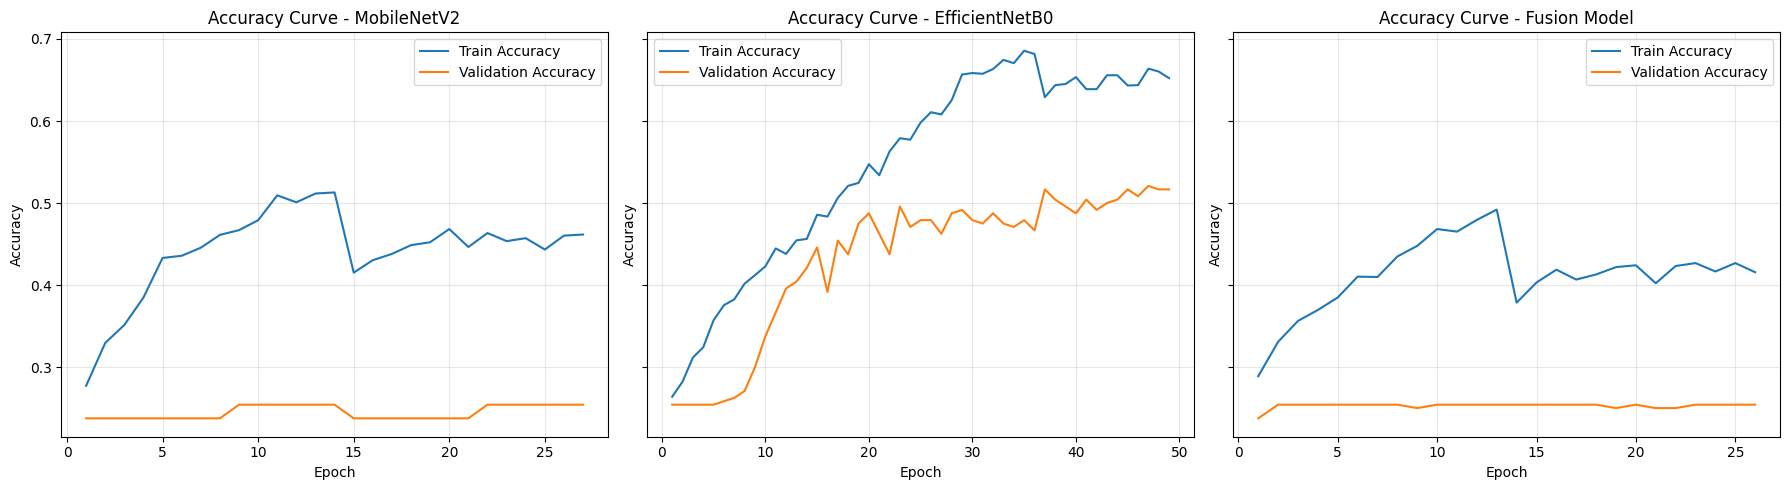

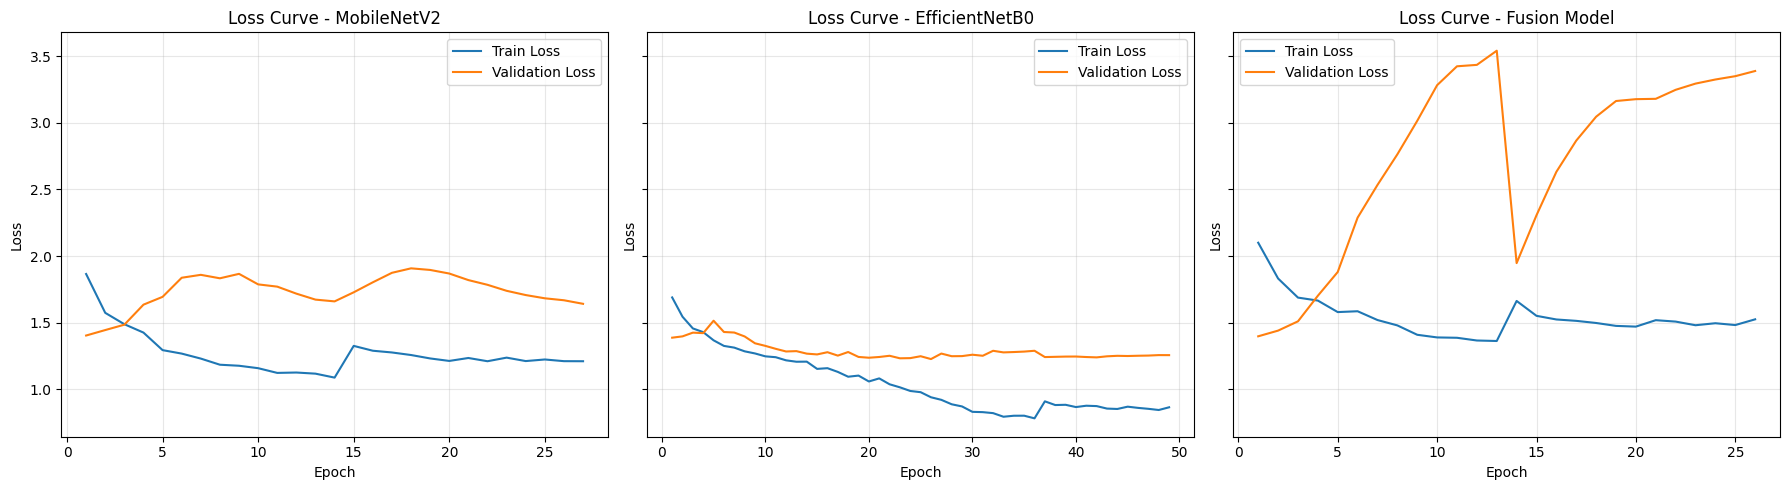

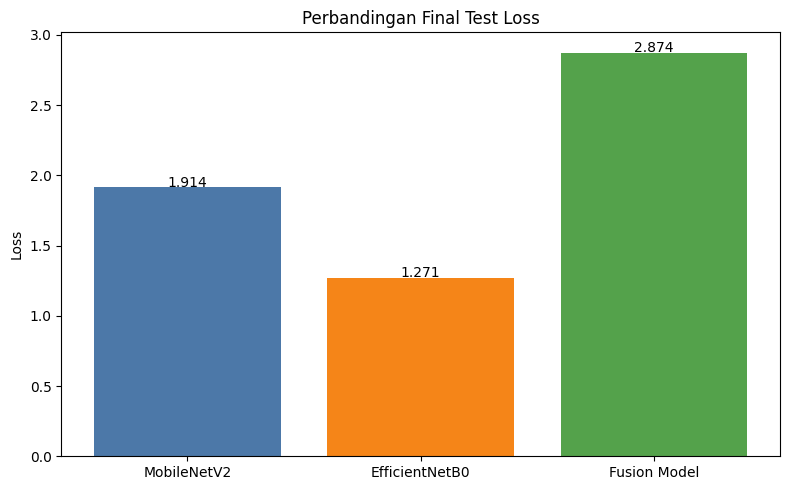

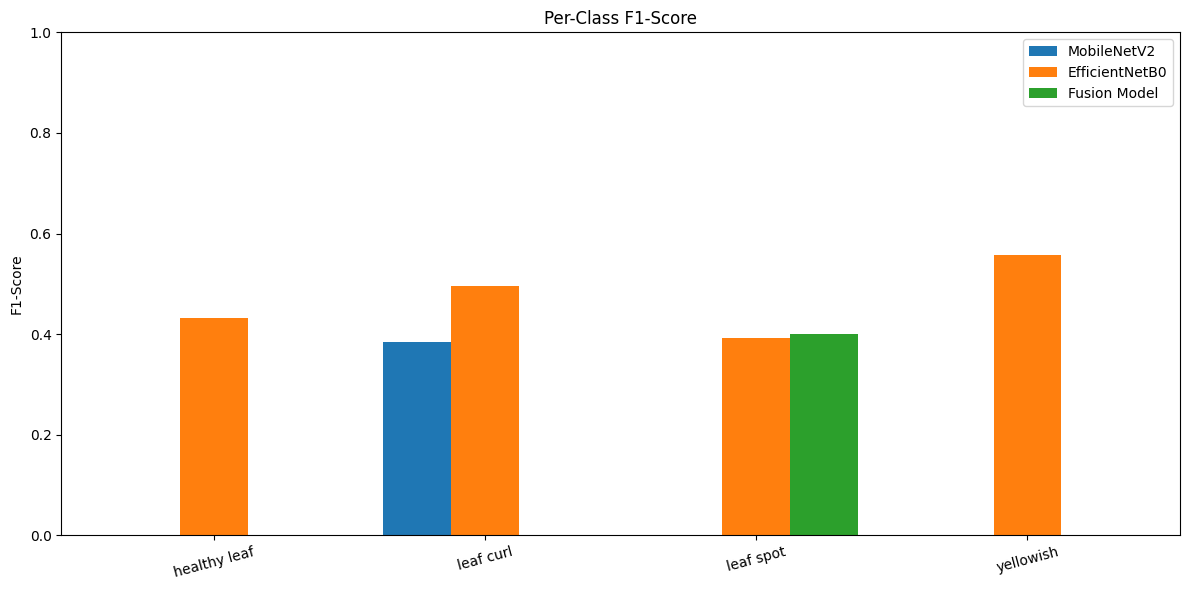

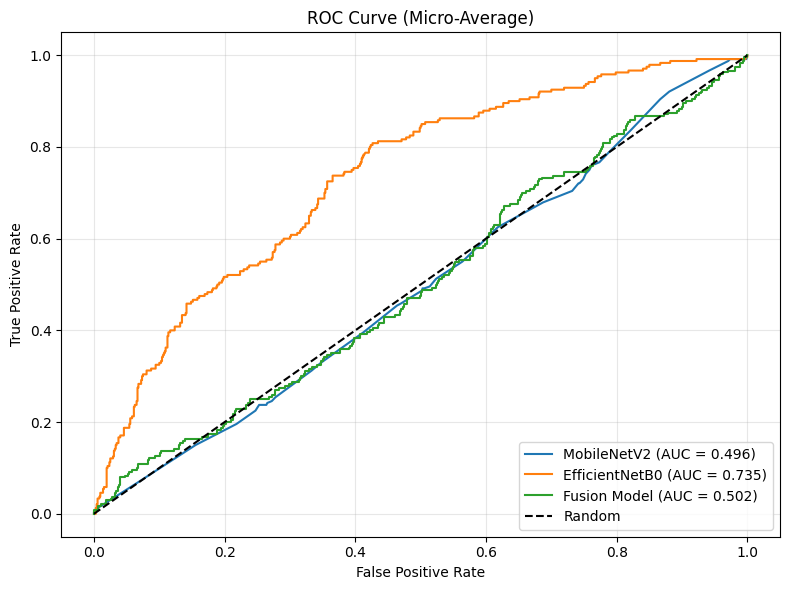

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,AUC,Training Time (sec)
1,EfficientNetB0,0.4792,0.4833,0.4792,0.4698,1.2713,0.7345,6905.7373
2,Fusion Model,0.2500,0.0625,0.2500,0.1000,2.8742,0.5020,6246.0170
0,MobileNetV2,0.2375,0.0564,0.2375,0.0912,1.9144,0.4964,2668.8679


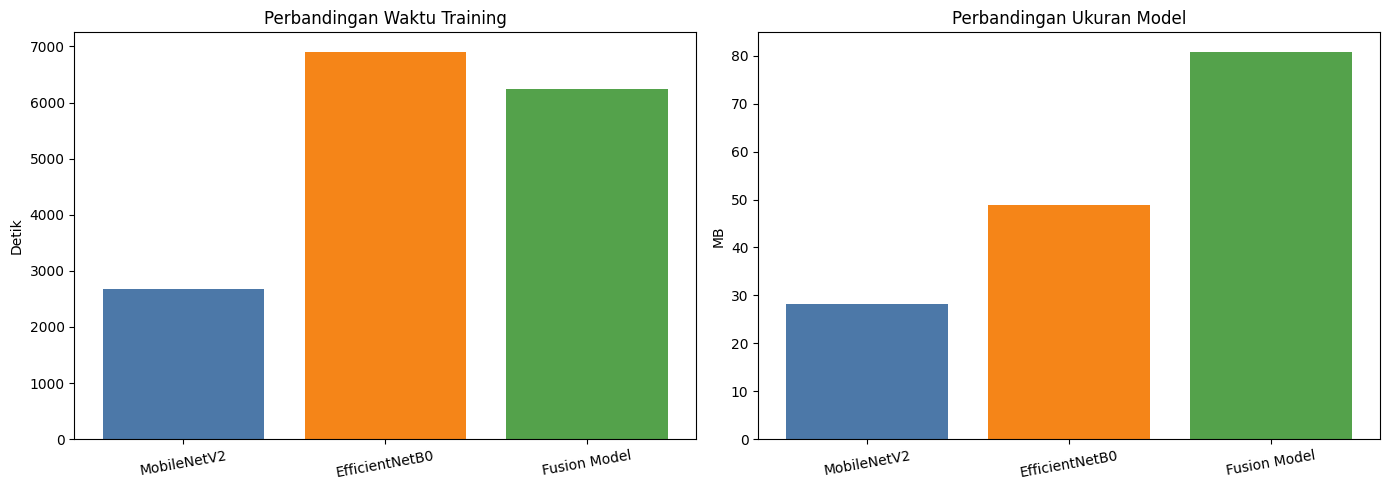


Insight cepat:
- Akurasi tertinggi: EfficientNetB0
- Gain Hybrid vs MobileNetV2: +1.25%
- Cek gap train vs validation untuk indikasi overfitting.
- Cek confusion matrix untuk kelas yang masih sering tertukar.


In [16]:
import pandas as pd
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

# Pastikan model tersedia di kernel
required_models = ["model_m", "model_e", "model_f"]
missing_models = [name for name in required_models if name not in globals()]
if missing_models :
    raise ValueError(
        "Model belum tersedia di kernel. Jalankan dulu cell 23, 25, dan 27. "
        f"Missing: {missing_models}"
    )

def build_eval_details(model, model_name) :
    test_data.reset()
    loss, acc = model.evaluate(test_data, verbose = 0)

    test_data.reset()
    x_batches, y_batches = [], []
    for _ in range(len(test_data)) :
        x_batch, y_batch = next(test_data)
        x_batches.append(x_batch)
        y_batches.append(y_batch)

    x_test = np.concatenate(x_batches, axis = 0)
    y_true = np.argmax(np.concatenate(y_batches, axis = 0), axis = 1)
    y_prob = model.predict(x_test, batch_size = BATCH_SIZE, verbose = 0)
    y_pred = np.argmax(y_prob, axis = 1)

    class_names_local = [
        name for name, _ in sorted(test_data.class_indices.items(), key = lambda item : item[1])
    ]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names = class_names_local,
        zero_division = 0,
        output_dict = True
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        "model_name" : model_name,
        "accuracy" : float(acc),
        "loss" : float(loss),
        "y_true" : y_true,
        "y_pred" : y_pred,
        "y_prob" : y_prob,
        "class_names" : class_names_local,
        "report_dict" : report_dict,
        "confusion_matrix" : cm
    }

# Jika detail evaluasi belum ada, hitung otomatis
if "eval_m" not in globals() :
    eval_m = build_eval_details(model_m, "MobileNetV2")
if "eval_e" not in globals() :
    eval_e = build_eval_details(model_e, "EfficientNetB0")
if "eval_f" not in globals() :
    eval_f = build_eval_details(model_f, "Fusion Model")

model_results = {
    "MobileNetV2" : eval_m,
    "EfficientNetB0" : eval_e,
    "Fusion Model" : eval_f
}

history_available = all(name in globals() for name in ["history_m", "history_e", "history_f"])
timing_available = all(name in globals() for name in ["timing_m", "timing_e", "timing_f"])

if history_available:
    model_histories = {
        "MobileNetV2" : history_m,
        "EfficientNetB0" : history_e,
        "Fusion Model" : history_f
    }
else:
    print("Info : history_* belum ada, grafik accuracy/loss curve tidak ditampilkan.")

if timing_available:
    model_timings = {
        "MobileNetV2" : timing_m,
        "EfficientNetB0" : timing_e,
        "Fusion Model" : timing_f
    }
else:
    print("Info : timing_* belum ada, perbandingan waktu training tidak ditampilkan.")

class_names = eval_m["class_names"]

def merge_history(history_bundle) :
    train_acc = history_bundle["stage1"].get("accuracy", []) + history_bundle["stage2"].get("accuracy", [])
    val_acc = history_bundle["stage1"].get("val_accuracy", []) + history_bundle["stage2"].get("val_accuracy", [])
    train_loss = history_bundle["stage1"].get("loss", []) + history_bundle["stage2"].get("loss", [])
    val_loss = history_bundle["stage1"].get("val_loss", []) + history_bundle["stage2"].get("val_loss", [])
    return train_acc, val_acc, train_loss, val_loss

def get_model_size_mb(model, filename) :
    model.save(filename, include_optimizer = False)
    size_mb = os.path.getsize(filename) / (1024 ** 2)
    os.remove(filename)
    return size_mb

# 1) Perbandingan Akurasi per Model
acc_df = pd.DataFrame({
    "Model" : list(model_results.keys()),
    "Accuracy" : [v["accuracy"] for v in model_results.values()],
})
plt.figure(figsize = (8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color = ["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha = "center")
plt.tight_layout()
plt.show()

best_model = acc_df.sort_values("Accuracy", ascending = False).iloc[0]
hybrid_gain_vs_mobilenet = (model_results["Fusion Model"]["accuracy"] - model_results["MobileNetV2"]["accuracy"]) * 100
print(f"Model akurasi tertinggi: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"Peningkatan Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")

# 2) Precision, Recall, F1-Score per Model
metric_rows = []
for model_name, result in model_results.items() :
    w = result["report_dict"]["weighted avg"]
    metric_rows.append({
        "Model" : model_name,
        "Precision" : w["precision"],
        "Recall" : w["recall"],
        "F1-Score" : w["f1-score"]
    })
metrics_df = pd.DataFrame(metric_rows)

x = np.arange(len(metrics_df))
w = 0.25
plt.figure(figsize = (10, 5))
plt.bar(x - w, metrics_df["Precision"], width = w, label = "Precision")
plt.bar(x, metrics_df["Recall"], width = w, label = "Recall")
plt.bar(x + w, metrics_df["F1-Score"], width = w, label = "F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Confusion Matrix (3 heatmap)
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
for ax, (model_name, result) in zip(axes, model_results.items()) :
    sns.heatmap(
        result["confusion_matrix"],
        annot = True,
        fmt = 'd',
        cmap = "Blues",
        xticklabels = class_names,
        yticklabels = class_names,
        ax = ax
    )
    ax.set_title(f"CM - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# 4) Training vs Validation Accuracy Curve
if history_available :
    fig, axes = plt.subplots(1, 3, figsize = (18, 5), sharey = True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()) :
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        ax.plot(epochs, train_acc, label = "Train Accuracy")
        ax.plot(epochs, val_acc, label = "Validation Accuracy")
        ax.set_title(f"Accuracy Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha = 0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 5) Training vs Validation Loss Curve
if history_available :
    fig, axes = plt.subplots(1, 3, figsize = (18, 5), sharey = True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()) :
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label = "Train Loss")
        ax.plot(epochs, val_loss, label = "Validation Loss")
        ax.set_title(f"Loss Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha = 0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

# 6) Perbandingan Loss Akhir
loss_df = pd.DataFrame({
    "Model" : list(model_results.keys()),
    "Final Test Loss" : [v["loss"] for v in model_results.values()]
})
plt.figure(figsize = (8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color = ["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha = "center")
plt.tight_layout()
plt.show()

# 7) F1-score per Kelas (grouped)
per_class_rows = []
for model_name, result in model_results.items() :
    for cls in class_names :
        per_class_rows.append({
            "Model" : model_name,
            "Class" : cls,
            "F1-Score" : result["report_dict"][cls]["f1-score"]
        })
per_class_df = pd.DataFrame(per_class_rows)

plt.figure(figsize = (12, 6))
for i, model_name in enumerate(model_results.keys()) :
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width = 0.25, label = model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation = 15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

# 8) ROC Curve + AUC (micro-average multiclass)
auc_scores = {}
plt.figure(figsize = (8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items() :
    y_true_bin = label_binarize(result["y_true"], classes = classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label = f"{model_name} (AUC = {roc_auc :.3f})")
plt.plot([0, 1], [0, 1], 'k--', label = "Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc = "lower right")
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# 9) Classification Report Table (Ringkasan)
summary_rows = []
for model_name, result in model_results.items() :
    w = result["report_dict"]["weighted avg"]
    summary_rows.append({
        "Model" : model_name,
        "Accuracy" : result["accuracy"],
        "Precision" : w["precision"],
        "Recall" : w["recall"],
        "F1-Score" : w["f1-score"],
        "Test Loss" : result["loss"],
        "AUC" : auc_scores[model_name],
        "Training Time (sec)" : model_timings[model_name]["total_sec"] if timing_available else np.nan
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending = False)
display(summary_df.round(4))

# 10) Waktu Training dan Ukuran Model
model_sizes_mb = {
    "MobileNetV2" : get_model_size_mb(model_m, "tmp_model_m.keras"),
    "EfficientNetB0" : get_model_size_mb(model_e, "tmp_model_e.keras"),
    "Fusion Model" : get_model_size_mb(model_f, "tmp_model_f.keras"),
}

if timing_available :
    efficiency_df = pd.DataFrame({
        "Model" : list(model_timings.keys()),
        "Training Time (sec)" : [v["total_sec"] for v in model_timings.values()],
        "Model Size (MB)" : [model_sizes_mb[name] for name in model_timings.keys()]
    })

    fig, axes = plt.subplots(1, 2, figsize = (14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color = ["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation = 10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color = ["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation = 10)

    plt.tight_layout()
    plt.show()
else:
    size_df = pd.DataFrame({
        "Model" : list(model_sizes_mb.keys()),
        "Model Size (MB)" : list(model_sizes_mb.values())
    })
    plt.figure(figsize = (8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color = ["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.show()

print("\nInsight cepat:")
print(f"- Akurasi tertinggi: {summary_df.iloc[0]['Model']}")
print(f"- Gain Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")
print("- Cek gap train vs validation untuk indikasi overfitting.")
print("- Cek confusion matrix untuk kelas yang masih sering tertukar.")

# 11. Export Grafik dan Tabel ke Folder Reports

In [ ]:
from pathlib import Path

base_dir = Path.cwd()
fig_dir = base_dir / "reports" / "figures"
metrics_dir = base_dir / "reports" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# Simpan tabel metrik
acc_df.to_csv(metrics_dir / "accuracy_per_model.csv", index=False)
metrics_df.to_csv(metrics_dir / "precision_recall_f1_per_model.csv", index=False)
loss_df.to_csv(metrics_dir / "final_loss_per_model.csv", index=False)
per_class_df.to_csv(metrics_dir / "f1_per_class_per_model.csv", index=False)
summary_df.to_csv(metrics_dir / "classification_summary_table.csv", index=False)

if "size_df" in globals():
    size_df.to_csv(metrics_dir / "model_size_comparison.csv", index=False)
if "efficiency_df" in globals():
    efficiency_df.to_csv(metrics_dir / "training_time_and_model_size.csv", index=False)

# 1) Accuracy per model
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "01_accuracy_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 2) Precision/Recall/F1 grouped
x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "02_precision_recall_f1_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 3) Confusion matrix per model
for idx, (model_name, result) in enumerate(model_results.items(), start=1):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    filename = f"03_confusion_matrix_{idx}_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

# 4) Accuracy curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_acc, label="Train Accuracy")
        plt.plot(epochs, val_acc, label="Validation Accuracy")
        plt.title(f"Accuracy Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"04_accuracy_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 5) Loss curve (jika history tersedia)
if "model_histories" in globals():
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_loss, label="Train Loss")
        plt.plot(epochs, val_loss, label="Validation Loss")
        plt.title(f"Loss Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"05_loss_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

# 6) Final loss comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "06_final_loss_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

# 7) Per-class F1 grouped
plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "07_f1_per_class_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

# 8) ROC curve
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    y_prob = result["y_prob"]
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve_micro_average.png", dpi=300, bbox_inches="tight")
plt.close()

# 10) Efficiency chart
if "efficiency_df" in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[0].set_title("Perbandingan Waktu Training")
    axes[0].set_ylabel("Detik")
    axes[0].tick_params(axis='x', rotation=10)

    axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    axes[1].set_title("Perbandingan Ukuran Model")
    axes[1].set_ylabel("MB")
    axes[1].tick_params(axis='x', rotation=10)

    plt.tight_layout()
    plt.savefig(fig_dir / "10_efficiency_time_and_size.png", dpi=300, bbox_inches="tight")
    plt.close()
elif "size_df" in globals():
    plt.figure(figsize=(8, 5))
    plt.bar(size_df["Model"], size_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
    plt.title("Perbandingan Ukuran Model")
    plt.ylabel("MB")
    plt.tight_layout()
    plt.savefig(fig_dir / "10_model_size_comparison.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"Export selesai: {fig_dir}")
print(f"Export selesai: {metrics_dir}")

Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\figures
Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\metrics
